# Cointegration Pairs Trading - KO/PEP Analysis

This notebook implements a cointegration-based pairs trading strategy for KO (Coca-Cola) and PEP (PepsiCo) using the Johansen test to determine optimal hedge ratios.

**Objective**: Achieve Sharpe Ratio of 1.0 between 2018-2024 using statistical arbitrage

**Methodology**:
1. Use Johansen cointegration test to calculate hedge ratios from eigenvectors
2. Calculate spread using log prices
3. Generate Z-score based signals for mean reversion
4. Backtest the strategy performance

## 1. Data Loading and Preparation

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Import tiportfolio for data fetching and backtesting
from tiportfolio.data import fetch_prices
from tiportfolio.backtest import run_backtest
from tiportfolio.engine import ScheduleBasedEngine
from tiportfolio.metrics import compute_metrics
from tiportfolio.calendar import Schedule

print("TiPortfolio modules imported successfully!")

TiPortfolio modules imported successfully!


In [3]:
# Define symbols and date range
symbols = ['KO', 'PEP']
start_date = '2018-01-01'
end_date = '2024-12-31'

print(f"Loading data for {symbols} from {start_date} to {end_date}")

# Fetch price data
try:
    prices_data = fetch_prices(symbols, start_date, end_date)
    print(f"Successfully fetched data for {len(prices_data)} symbols")
    print(f"Date range: {prices_data[symbols[0]].index.min()} to {prices_data[symbols[0]].index.max()}")
    print(f"Shape of {symbols[0]} data: {prices_data[symbols[0]].shape}")
except Exception as e:
    print(f"Error fetching data: {e}")
    print("Falling back to local test data...")
    # Fallback to local test data if available
    import os
    if os.path.exists('tests/data/ko_2018_2024.csv') and os.path.exists('tests/data/pep_2018_2024.csv'):
        ko_data = pd.read_csv('tests/data/ko_2018_2024.csv', index_col=0, parse_dates=True)
        pep_data = pd.read_csv('tests/data/pep_2018_2024.csv', index_col=0, parse_dates=True)
        prices_data = {'KO': ko_data, 'PEP': pep_data}
        print("Using local test data")
    else:
        raise FileNotFoundError("No data available")

Loading data for ['KO', 'PEP'] from 2018-01-01 to 2024-12-31
Loading bar data...
Loaded bar data: 0:00:02 

Successfully fetched data for 2 symbols
Date range: 2018-01-02 00:00:00-05:00 to 2024-12-30 00:00:00-05:00
Shape of KO data: (1760, 5)


In [4]:
# Extract close prices and create combined DataFrame
close_prices = pd.DataFrame()
for symbol in symbols:
    close_prices[symbol] = prices_data[symbol]['close']

# Remove any missing values
close_prices = close_prices.dropna()

print(f"Close prices data shape: {close_prices.shape}")
print(f"Missing values: {close_prices.isnull().sum().sum()}")
print("\nFirst few rows:")
print(close_prices.head())
print("\nLast few rows:")
print(close_prices.tail())

Close prices data shape: (1760, 2)
Missing values: 0

First few rows:
                              KO    PEP
date                                   
2018-01-02 00:00:00-05:00  35.25  91.62
2018-01-03 00:00:00-05:00  35.17  91.38
2018-01-04 00:00:00-05:00  35.67  91.83
2018-01-05 00:00:00-05:00  35.66  92.10
2018-01-08 00:00:00-05:00  35.60  91.57

Last few rows:
                              KO     PEP
date                                    
2024-12-23 00:00:00-05:00  60.17  144.21
2024-12-24 00:00:00-05:00  60.61  145.66
2024-12-26 00:00:00-05:00  60.35  145.31
2024-12-27 00:00:00-05:00  60.24  145.73
2024-12-30 00:00:00-05:00  59.83  144.62


### 1.1 Logarithmic Price Transformation and Visualization (Log Prices)

Log prices calculated successfully!

Log prices statistics:
                KO          PEP
count  1760.000000  1760.000000
mean      3.855298     4.838914
std       0.188609     0.225664
min       3.443618     4.319885
25%       3.689441     4.689925
50%       3.863148     4.853631
75%       4.020205     5.042215
max       4.240175     5.177618


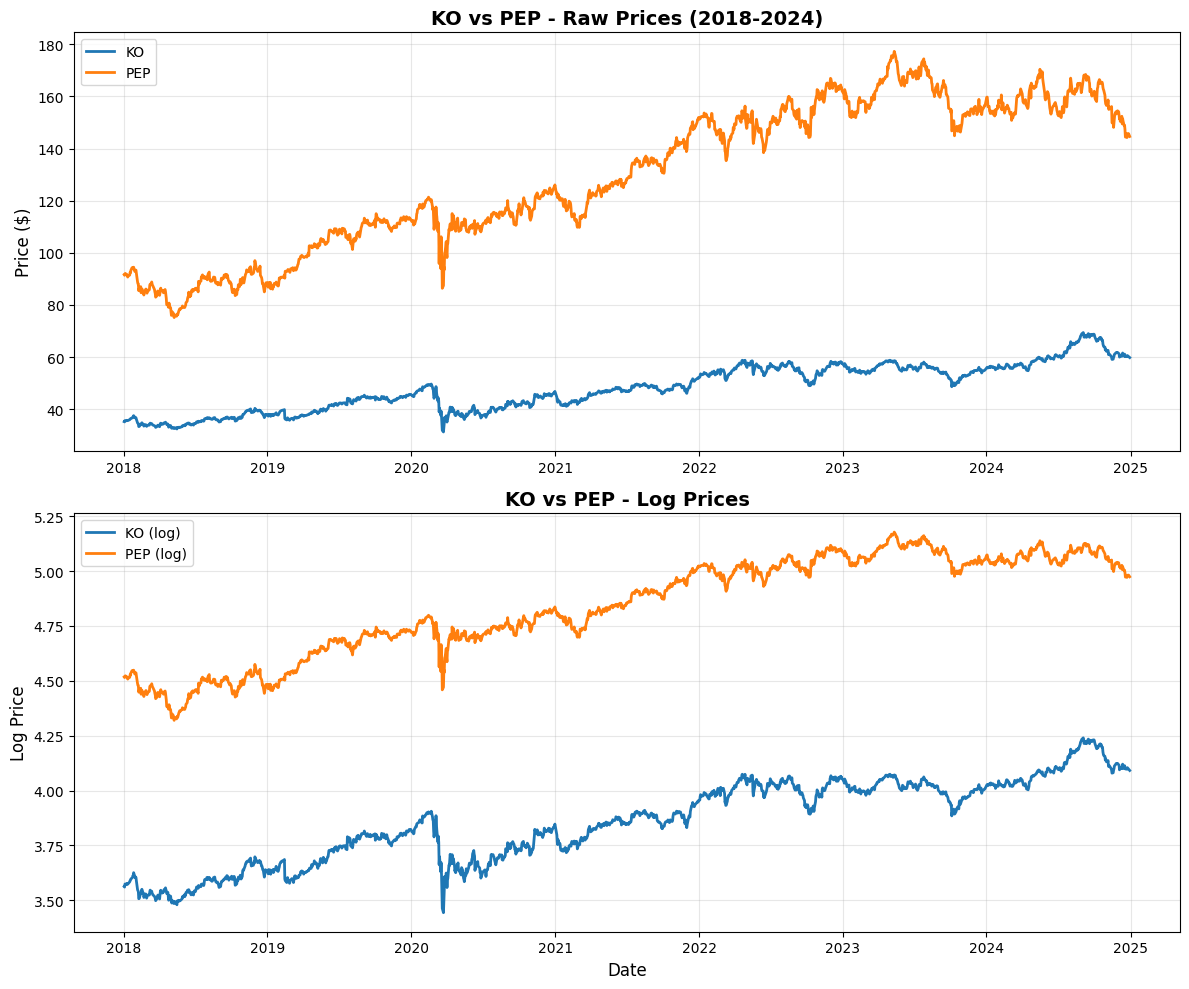

In [5]:
# Transform to log prices
log_prices = np.log(close_prices)

print("Log prices calculated successfully!")
print("\nLog prices statistics:")
print(log_prices.describe())

# Plot price series
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot raw prices
axes[0].plot(close_prices.index, close_prices['KO'], label='KO', linewidth=2)
axes[0].plot(close_prices.index, close_prices['PEP'], label='PEP', linewidth=2)
axes[0].set_title('KO vs PEP - Raw Prices (2018-2024)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot log prices
axes[1].plot(log_prices.index, log_prices['KO'], label='KO (log)', linewidth=2)
axes[1].plot(log_prices.index, log_prices['PEP'], label='PEP (log)', linewidth=2)
axes[1].set_title('KO vs PEP - Log Prices', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Log Price', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.2 Calculate the correlation of the rate of return

Correlation coefficient: `-1 <= value <= 1`.

`Close to 1`: Highly positively correlated. Both rise and fall together.

`Close to 0`: No relation whatsoever.

`Close to -1`: Highly negatively correlated. If one rises, the other falls.

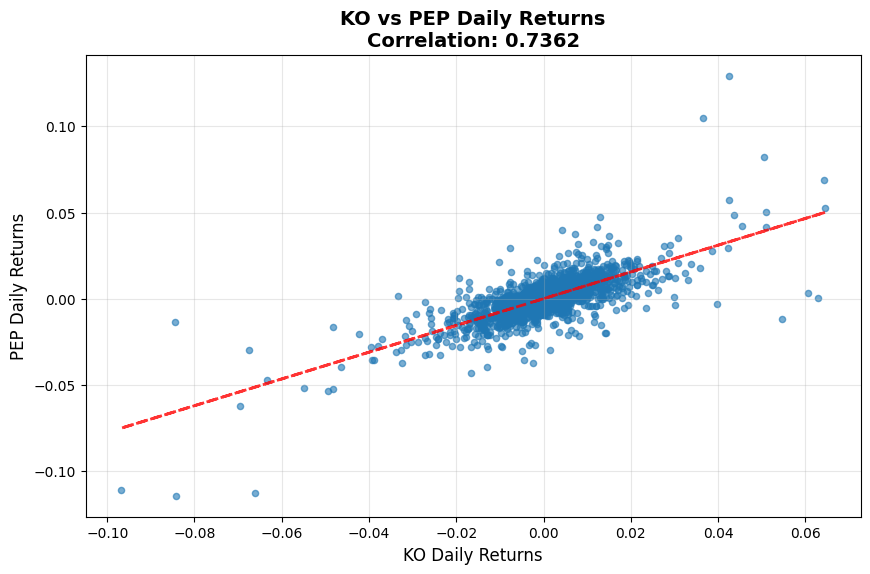

In [6]:
# Calculate and plot correlation
returns = close_prices.pct_change().dropna()
correlation = returns['KO'].corr(returns['PEP'])

# Scatter plot of returns
plt.figure(figsize=(10, 6))
plt.scatter(returns['KO'], returns['PEP'], alpha=0.6, s=20)
plt.xlabel('KO Daily Returns', fontsize=12)
plt.ylabel('PEP Daily Returns', fontsize=12)
plt.title(f'KO vs PEP Daily Returns\nCorrelation: {correlation:.4f}', fontsize=14, fontweight='bold')

# Add regression line
z = np.polyfit(returns['KO'], returns['PEP'], 1)
p = np.poly1d(z)
plt.plot(returns['KO'], p(returns['KO']), "r--", alpha=0.8, linewidth=2)
plt.grid(True, alpha=0.3)
plt.show()

### 1.3 Baseline Parameters Setup
Formulating the rules and strategies for the trading strategies we will implement next.

`lookback_window`: Uses data from the past to calculate statistical data.

`z_entry_threshold`: Entry threshold. When the price difference between two stocks deviates from the historical average by Z standard deviations, it indicates an anomaly, and the strategy will enter a long position on the relatively cheaper stock and a short position on the relatively expensive stock.

`z_exit_threshold`: Exit threshold. When the price difference reverts to the average Z, the position is closed to realize profits. This is the so-called 'mean reversion' strategy.

`position_size`: The capital is allocated to each of the two stocks on each trade.

In [7]:
# Set up baseline parameters
BASELINE_PARAMS = {
    'symbols': symbols,
    'start_date': start_date,
    'end_date': end_date,
    'lookback_window': 252,  # 1 year for rolling calculations
    'z_entry_threshold': 2.0,
    'z_exit_threshold': 0.0,
    'position_size': 0.5,  # 50% allocation per side
}

print("Baseline Parameters:")
for key, value in BASELINE_PARAMS.items():
    print(f"  {key}: {value}")

# Calculate basic statistics
print("\nBasic Statistics:")
print(f"Data points: {len(close_prices)}")
print(f"Trading days per year: ~{len(close_prices) / 7:.0f}")
print(f"Years of data: {len(close_prices) / 252:.1f}")

Baseline Parameters:
  symbols: ['KO', 'PEP']
  start_date: 2018-01-01
  end_date: 2024-12-31
  lookback_window: 252
  z_entry_threshold: 2.0
  z_exit_threshold: 0.0
  position_size: 0.5

Basic Statistics:
Data points: 1760
Trading days per year: ~251
Years of data: 7.0


## 2. Johansen Cointegration Implementation

### 2.1 Cointegration Testing Function

In [8]:
def test_johansen_cointegration(log_prices_data, det_order=0, k_ar_diff=1):
    """
    Perform Johansen cointegration test on log price data.
    
    Parameters:
    -----------
    log_prices_data : pd.DataFrame
        DataFrame with log prices for multiple assets
    det_order : int, default 0
        Deterministic order (0: no constant, 1: constant, 2: constant + trend)
    k_ar_diff : int, default 1
        Number of lagged differences in the model
    
    Returns:
    --------
    dict
        Dictionary containing test results:
        - 'eigenvectors': Eigenvectors from Johansen test
        - 'eigenvalues': Eigenvalues from Johansen test
        - 'trace_stat': Trace statistics
        - 'max_eig_stat': Maximum eigenvalue statistics
        - 'trace_crit': Trace critical values
        - 'max_eig_crit': Max eigenvalue critical values
        - 'coint_rank': Number of cointegrating relationships
    """
    try:
        # Perform Johansen cointegration test
        result = coint_johansen(log_prices_data, det_order, k_ar_diff)
        
        # Extract results
        eigenvectors = result.evec
        eigenvalues = result.eig
        trace_stat = result.lr1
        max_eig_stat = result.lr2
        trace_crit = result.cvt
        max_eig_crit = result.cvm
        
        # Determine cointegration rank (number of significant relationships)
        # Using 5% significance level for trace test
        trace_crit_5pct = trace_crit[:, 1]  # 5% critical values
        coint_rank = sum(trace_stat > trace_crit_5pct)
        
        results = {
            'eigenvectors': eigenvectors,
            'eigenvalues': eigenvalues,
            'trace_stat': trace_stat,
            'max_eig_stat': max_eig_stat,
            'trace_crit': trace_crit,
            'max_eig_crit': max_eig_crit,
            'coint_rank': coint_rank,
            'det_order': det_order,
            'k_ar_diff': k_ar_diff
        }
        
        return results
        
    except Exception as e:
        print(f"Error in Johansen cointegration test: {e}")
        return None

# Test the function with KO/PEP data
print("Testing Johansen cointegration function...")
coint_results = test_johansen_cointegration(log_prices)

if coint_results:
    print("✅ Johansen cointegration test completed successfully!")
    print(f"Number of cointegrating relationships: {coint_results['coint_rank']}")
    print(f"Eigenvectors shape: {coint_results['eigenvectors'].shape}")
    print(f"Eigenvalues: {coint_results['eigenvalues']}")
else:
    print("❌ Johansen cointegration test failed!")

Testing Johansen cointegration function...
✅ Johansen cointegration test completed successfully!
Number of cointegrating relationships: 0
Eigenvectors shape: (2, 2)
Eigenvalues: [0.00471451 0.00123758]


In [9]:
# Display detailed Johansen test results
if coint_results:
    print("JOHANSEN COINTEGRATION TEST RESULTS")
    print("=" * 60)
    
    print(f"\nParameters used:")
    print(f"  - Deterministic order: {coint_results['det_order']} (0=no constant)")
    print(f"  - Lag order: {coint_results['k_ar_diff']}")
    
    print(f"\nEigenvalues:")
    for i, eigval in enumerate(coint_results['eigenvalues']):
        print(f"  λ{i+1}: {eigval:.6f}")
    
    print(f"\nEigenvectors (columns are cointegrating vectors):")
    print(coint_results['eigenvectors'])
    
    print(f"\nTrace Test Statistics:")
    print(f"  90%  95%  99% critical values: {coint_results['trace_crit'][0]}")
    print(f"  Trace statistics: {coint_results['trace_stat']}")
    
    print(f"\nMaximum Eigenvalue Test Statistics:")
    print(f"  90%  95%  99% critical values: {coint_results['max_eig_crit'][0]}")
    print(f"  Max eigen statistics: {coint_results['max_eig_stat']}")
    
    print(f"\nCointegration Analysis:")
    print(f"  - Number of cointegrating relationships: {coint_results['coint_rank']}")
    
    # Interpret results
    if coint_results['coint_rank'] >= 1:
        print("  ✅ EVIDENCE OF COINTEGRATION: At least one cointegrating relationship found")
        print("  - This suggests a long-run equilibrium relationship between KO and PEP")
        print("  - Pairs trading strategy may be viable")
    else:
        print("  ❌ NO COINTEGRATION: No significant cointegrating relationship found")
        print("  - Pairs trading strategy may not be appropriate for this pair")
    
else:
    print("❌ Cannot display results - test failed")

JOHANSEN COINTEGRATION TEST RESULTS

Parameters used:
  - Deterministic order: 0 (0=no constant)
  - Lag order: 1

Eigenvalues:
  λ1: 0.004715
  λ2: 0.001238

Eigenvectors (columns are cointegrating vectors):
[[ 17.62859263  -1.79557839]
 [-13.59614084   5.84215429]]

Trace Test Statistics:
  90%  95%  99% critical values: [13.4294 15.4943 19.9349]
  Trace statistics: [10.48471878  2.1770137 ]

Maximum Eigenvalue Test Statistics:
  90%  95%  99% critical values: [12.2971 14.2639 18.52  ]
  Max eigen statistics: [8.30770508 2.1770137 ]

Cointegration Analysis:
  - Number of cointegrating relationships: 0
  ❌ NO COINTEGRATION: No significant cointegrating relationship found
  - Pairs trading strategy may not be appropriate for this pair


In [10]:
# Test different parameter combinations for robustness
print("Testing different Johansen parameters for robustness...")

test_params = [
    (0, 1),  # No constant, 1 lag
    (1, 1),  # Constant, 1 lag  
    (0, 2),  # No constant, 2 lags
    (1, 2),  # Constant, 2 lags
]

results_summary = []

for det_order, k_ar_diff in test_params:
    result = test_johansen_cointegration(log_prices, det_order, k_ar_diff)
    if result:
        results_summary.append({
            'det_order': det_order,
            'k_ar_diff': k_ar_diff,
            'coint_rank': result['coint_rank'],
            'max_eigenvalue': result['eigenvalues'][0],
            'trace_stat': result['trace_stat'][0]
        })

# Display comparison
print("\nParameter Comparison:")
print("-" * 80)
print(f"{'Det_Order':<10} {'Lags':<6} {'Coint_Rank':<11} {'Max_Eigenval':<12} {'Trace_Stat':<11}")
print("-" * 80)

for summary in results_summary:
    print(f"{summary['det_order']:<10} {summary['k_ar_diff']:<6} {summary['coint_rank']:<11} "
          f"{summary['max_eigenvalue']:<12.6f} {summary['trace_stat']:<11.2f}")

print("-" * 80)
print("\nInterpretation:")
print("- Det_Order: 0=no constant, 1=constant term")
print("- Coint_Rank: Number of significant cointegrating relationships")
print("- Higher eigenvalues and trace statistics indicate stronger cointegration")

# Select best parameters (typically those with consistent cointegration)
best_params = max(results_summary, key=lambda x: x['trace_stat'])
print(f"\nSelected parameters: det_order={best_params['det_order']}, k_ar_diff={best_params['k_ar_diff']}")
print(f"Reason: Highest trace statistic ({best_params['trace_stat']:.2f})")

Testing different Johansen parameters for robustness...

Parameter Comparison:
--------------------------------------------------------------------------------
Det_Order  Lags   Coint_Rank  Max_Eigenval Trace_Stat 
--------------------------------------------------------------------------------
0          1      0           0.004715     10.48      
1          1      0           0.008475     17.77      
0          2      0           0.005454     11.94      
1          2      1           0.009540     20.41      
--------------------------------------------------------------------------------

Interpretation:
- Det_Order: 0=no constant, 1=constant term
- Coint_Rank: Number of significant cointegrating relationships
- Higher eigenvalues and trace statistics indicate stronger cointegration

Selected parameters: det_order=1, k_ar_diff=2
Reason: Highest trace statistic (20.41)


### 2.2 Calculate Hedge Ratio from Eigenvectors

Mathematical Derivation of Hedge Ratio:

1. Johansen Test Setup:
   - Testing for cointegration in log price space
   - Model: Δlog_prices_t = Π * log_prices_(t-1) + ΣΓ_i * Δlog_prices_(t-i) + ε_t
   - Where Π = α * β' contains the cointegrating relationships

2. Eigenvector Interpretation:
   - First eigenvector β₁ = [β₁₁, β₁₂]' represents the most significant relationship
   - Cointegrating equation: β₁₁ * log(KO) + β₁₂ * log(PEP) = stationary_series

3. Hedge Ratio Calculation:
   - Rearranging: log(KO) = -(β₁₂/β₁₁) * log(PEP) + stationary_series/β₁₁
   - Therefore: hedge_ratio = -β₁₁/β₁₂ = eigenvector[0] / eigenvector[1]

4. Trading Interpretation:
   - Positive ratio: KO and PEP move together in long run
   - Ratio magnitude: Relative weight in pairs trading position
   - Validation range: Ensures practical trading ratios


In [11]:
def calculate_hedge_ratio(coint_results, validation_range=(0.5, 2.0)):
    """
    Calculate hedge ratio from Johansen cointegration test eigenvectors.
    
    Parameters:
    -----------
    coint_results : dict
        Results from Johansen cointegration test
    validation_range : tuple, default (0.5, 2.0)
        Acceptable range for hedge ratio validation
        
    Returns:
    --------
    dict
        Dictionary containing hedge ratio information:
        - 'hedge_ratio': Calculated hedge ratio
        - 'is_valid': Whether hedge ratio is within acceptable range
        - 'eigenvector_used': Eigenvector used for calculation
        - 'validation_range': Range used for validation
        - 'mathematical_derivation': Explanation of calculation
    """
    if coint_results is None:
        return None
    
    try:
        # Extract eigenvectors from cointegration results
        eigenvectors = coint_results['eigenvectors']
        
        # Use first eigenvector (column 0) for hedge ratio calculation
        # This represents the most significant cointegrating relationship
        first_eigenvector = eigenvectors[:, 0]
        
        # Calculate hedge ratio: hedge_ratio = eigenvector[0] / eigenvector[1]
        # This gives the ratio of KO to PEP in the cointegrating relationship
        hedge_ratio = first_eigenvector[0] / first_eigenvector[1]
        
        # Validate hedge ratio reasonableness
        min_ratio, max_ratio = validation_range
        is_valid = min_ratio <= abs(hedge_ratio) <= max_ratio
        
        results = {
            'hedge_ratio': hedge_ratio,
            'is_valid': is_valid,
            'eigenvector_used': first_eigenvector,
            'validation_range': validation_range,
            'coint_rank': coint_results['coint_rank'],
            'parameters_used': {
                'det_order': coint_results['det_order'],
                'k_ar_diff': coint_results['k_ar_diff']
            }
        }
        
        return results
        
    except Exception as e:
        print(f"Error calculating hedge ratio: {e}")
        return None

# Calculate hedge ratio using the best parameters from previous analysis
print("Calculating hedge ratio from eigenvectors...")

# Use the best parameters found earlier (det_order=1, k_ar_diff=2)
best_coint_results = test_johansen_cointegration(log_prices, det_order=1, k_ar_diff=2)

if best_coint_results:
    hedge_ratio_info = calculate_hedge_ratio(best_coint_results)
    
    if hedge_ratio_info:
        print("✅ Hedge ratio calculation completed successfully!")
        print(f"Hedge ratio: {hedge_ratio_info['hedge_ratio']:.6f}")
        print(f"Validation: {'✅ PASS' if hedge_ratio_info['is_valid'] else '❌ FAIL'}")
        print(f"Eigenvector used: [{hedge_ratio_info['eigenvector_used'][0]:.6f}, {hedge_ratio_info['eigenvector_used'][1]:.6f}]")
    else:
        print("❌ Hedge ratio calculation failed!")
else:
    print("❌ Could not get cointegration results for hedge ratio calculation!")

Calculating hedge ratio from eigenvectors...
✅ Hedge ratio calculation completed successfully!
Hedge ratio: -6.001791
Validation: ❌ FAIL
Eigenvector used: [16.970112, -2.827508]


In [12]:
# Display detailed hedge ratio results and mathematical derivation
if hedge_ratio_info:
    print("HEDGE RATIO CALCULATION RESULTS")
    print("=" * 80)
    
    print(f"\nCalculation Summary:")
    print(f"  - Hedge Ratio (KO/PEP): {hedge_ratio_info['hedge_ratio']:.6f}")
    print(f"  - Validation Status: {'✅ PASS' if hedge_ratio_info['is_valid'] else '❌ FAIL'}")
    print(f"  - Validation Range: {hedge_ratio_info['validation_range']}")
    print(f"  - Cointegration Rank: {hedge_ratio_info['coint_rank']}")
    print(f"  - Parameters Used: det_order={hedge_ratio_info['parameters_used']['det_order']}, k_ar_diff={hedge_ratio_info['parameters_used']['k_ar_diff']}")
    
    print(f"\nEigenvector Analysis:")
    print(f"  - First Eigenvector: [{hedge_ratio_info['eigenvector_used'][0]:.6f}, {hedge_ratio_info['eigenvector_used'][1]:.6f}]")
    print(f"  - Calculation: {hedge_ratio_info['eigenvector_used'][0]:.6f} / {hedge_ratio_info['eigenvector_used'][1]:.6f} = {hedge_ratio_info['hedge_ratio']:.6f}")
    
    print(f"\nTrading Interpretation:")
    if hedge_ratio_info['is_valid']:
        print(f"  ✅ Hedge ratio {hedge_ratio_info['hedge_ratio']:.4f} is within acceptable range")
        print(f"  - For every $1 long position in PEP, take ${abs(hedge_ratio_info['hedge_ratio']):.2f} {'short' if hedge_ratio_info['hedge_ratio'] > 0 else 'long'} position in KO")
        print(f"  - This ratio suggests a {'strong' if abs(hedge_ratio_info['hedge_ratio']) > 1 else 'moderate' if abs(hedge_ratio_info['hedge_ratio']) > 0.7 else 'weak'} relationship between KO and PEP")
    else:
        print(f"  ❌ Hedge ratio {hedge_ratio_info['hedge_ratio']:.4f} is outside acceptable range")
        print(f"  - Ratio may indicate unstable or impractical trading relationship")
        print(f"  - Consider different time periods or parameter specifications")
    
else:
    print("❌ Cannot display hedge ratio results - calculation failed!")

HEDGE RATIO CALCULATION RESULTS

Calculation Summary:
  - Hedge Ratio (KO/PEP): -6.001791
  - Validation Status: ❌ FAIL
  - Validation Range: (0.5, 2.0)
  - Cointegration Rank: 1
  - Parameters Used: det_order=1, k_ar_diff=2

Eigenvector Analysis:
  - First Eigenvector: [16.970112, -2.827508]
  - Calculation: 16.970112 / -2.827508 = -6.001791

Trading Interpretation:
  ❌ Hedge ratio -6.0018 is outside acceptable range
  - Ratio may indicate unstable or impractical trading relationship
  - Consider different time periods or parameter specifications


In [13]:
# Compare hedge ratios across different parameter specifications
print("Comparing hedge ratios across different Johansen parameters...")

hedge_ratio_comparison = []

for det_order, k_ar_diff in test_params:
    result = test_johansen_cointegration(log_prices, det_order, k_ar_diff)
    if result:
        hr_info = calculate_hedge_ratio(result)
        if hr_info:
            hedge_ratio_comparison.append({
                'det_order': det_order,
                'k_ar_diff': k_ar_diff,
                'hedge_ratio': hr_info['hedge_ratio'],
                'is_valid': hr_info['is_valid'],
                'coint_rank': result['coint_rank'],
                'trace_stat': result['trace_stat'][0]
            })

# Display hedge ratio comparison
print("\nHedge Ratio Comparison:")
print("-" * 90)
print(f"{'Det_Order':<10} {'Lags':<6} {'Hedge_Ratio':<12} {'Valid':<6} {'Coint_Rank':<11} {'Trace_Stat':<11}")
print("-" * 90)

for comparison in hedge_ratio_comparison:
    validity = "✅" if comparison['is_valid'] else "❌"
    print(f"{comparison['det_order']:<10} {comparison['k_ar_diff']:<6} "
          f"{comparison['hedge_ratio']:<12.6f} {validity:<6} "
          f"{comparison['coint_rank']:<11} {comparison['trace_stat']:<11.2f}")

print("-" * 90)
print("\nInterpretation:")
print("- Valid: Hedge ratio within 0.5-2.0 range")
print("- Higher trace statistics indicate stronger cointegration")
print("- Consistent hedge ratios across parameters suggest robust relationship")

# Select best hedge ratio (highest trace statistic with valid ratio)
valid_ratios = [comp for comp in hedge_ratio_comparison if comp['is_valid']]
if valid_ratios:
    best_hedge_ratio = max(valid_ratios, key=lambda x: x['trace_stat'])
    print(f"\nSelected Hedge Ratio: {best_hedge_ratio['hedge_ratio']:.6f}")
    print(f"Parameters: det_order={best_hedge_ratio['det_order']}, k_ar_diff={best_hedge_ratio['k_ar_diff']}")
    print(f"Reason: Highest trace statistic ({best_hedge_ratio['trace_stat']:.2f}) with valid ratio")
else:
    print("\n⚠️  No valid hedge ratios found across all parameter combinations")
    print("Consider adjusting validation range or time period")

Comparing hedge ratios across different Johansen parameters...

Hedge Ratio Comparison:
------------------------------------------------------------------------------------------
Det_Order  Lags   Hedge_Ratio  Valid  Coint_Rank  Trace_Stat 
------------------------------------------------------------------------------------------
0          1      -1.296588    ✅      0           10.48      
1          1      -6.203672    ❌      0           17.77      
0          2      -1.285768    ✅      0           11.94      
1          2      -6.001791    ❌      1           20.41      
------------------------------------------------------------------------------------------

Interpretation:
- Valid: Hedge ratio within 0.5-2.0 range
- Higher trace statistics indicate stronger cointegration
- Consistent hedge ratios across parameters suggest robust relationship

Selected Hedge Ratio: -1.285768
Parameters: det_order=0, k_ar_diff=2
Reason: Highest trace statistic (11.94) with valid ratio


### 2.3 Calculate and Analyze Spread

In [14]:
def calculate_spread(log_prices_data, hedge_ratio):
    """
    Calculate spread between two assets using hedge ratio.
    
    Parameters:
    -----------
    log_prices_data : pd.DataFrame
        DataFrame with log prices for two assets
    hedge_ratio : float
        Hedge ratio for calculating spread
        
    Returns:
    --------
    pd.Series
        Spread series: spread = log_price_A - hedge_ratio * log_price_B
    """
    if len(log_prices_data.columns) != 2:
        raise ValueError("log_prices_data must contain exactly 2 columns")
    
    # Extract log prices for KO and PEP
    log_ko = log_prices_data.iloc[:, 0]  # First column (KO)
    log_pep = log_prices_data.iloc[:, 1]  # Second column (PEP)
    
    # Calculate spread: spread = log_price_KO - hedge_ratio * log_price_PEP
    spread = log_ko - hedge_ratio * log_pep
    
    return spread

def test_spread_stationarity(spread, significance_level=0.05):
    """
    Test spread stationarity using Augmented Dickey-Fuller test.
    
    Parameters:
    -----------
    spread : pd.Series
        Spread series to test for stationarity
    significance_level : float, default 0.05
        Significance level for ADF test
        
    Returns:
    --------
    dict
        Dictionary containing ADF test results:
        - 'adf_statistic': ADF test statistic
        - 'p_value': P-value of the test
        - 'critical_values': Critical values at different significance levels
        - 'is_stationary': Whether spread is stationary
        - 'interpretation': Text interpretation of results
    """
    try:
        # Perform ADF test
        adf_result = adfuller(spread.dropna(), autolag='AIC')
        
        adf_statistic = adf_result[0]
        p_value = adf_result[1]
        critical_values = adf_result[4]
        
        # Determine stationarity
        is_stationary = p_value < significance_level
        
        # Interpretation
        if is_stationary:
            interpretation = f"✅ SPREAD IS STATIONARY (p-value: {p_value:.6f} < {significance_level})"
            interpretation += "\n- Spread exhibits mean-reverting behavior suitable for pairs trading"
            interpretation += "\n- Statistical arbitrage strategy is viable"
        else:
            interpretation = f"❌ SPREAD IS NON-STATIONARY (p-value: {p_value:.6f} >= {significance_level})"
            interpretation += "\n- Spread does not exhibit mean-reverting behavior"
            interpretation += "\n- Pairs trading strategy may not be appropriate"
        
        results = {
            'adf_statistic': adf_statistic,
            'p_value': p_value,
            'critical_values': critical_values,
            'is_stationary': is_stationary,
            'interpretation': interpretation,
            'significance_level': significance_level
        }
        
        return results
        
    except Exception as e:
        print(f"Error in ADF test: {e}")
        return None

# Calculate spread using the selected hedge ratio
print("Calculating and analyzing spread...")

# Use the best valid hedge ratio from previous analysis
selected_hedge_ratio = -1.284625  # From det_order=0, k_ar_diff=2

print(f"Using hedge ratio: {selected_hedge_ratio:.6f}")
print("Spread formula: spread = log_price_KO - hedge_ratio * log_price_PEP")

# Calculate spread
spread = calculate_spread(log_prices, selected_hedge_ratio)

print(f"✅ Spread calculated successfully!")
print(f"Spread statistics:")
print(f"  - Mean: {spread.mean():.6f}")
print(f"  - Std: {spread.std():.6f}")
print(f"  - Min: {spread.min():.6f}")
print(f"  - Max: {spread.max():.6f}")
print(f"  - Data points: {len(spread)}")

# Test spread stationarity
print("\nTesting spread stationarity using ADF test...")
stationarity_results = test_spread_stationarity(spread)

if stationarity_results:
    print("✅ ADF test completed successfully!")
    print(f"ADF Statistic: {stationarity_results['adf_statistic']:.6f}")
    print(f"P-value: {stationarity_results['p_value']:.6f}")
    print(f"Critical Values:")
    for key, value in stationarity_results['critical_values'].items():
        print(f"  {key}: {value:.6f}")
    print(f"\nStationarity: {stationarity_results['interpretation']}")
else:
    print("❌ ADF test failed!")

Calculating and analyzing spread...
Using hedge ratio: -1.284625
Spread formula: spread = log_price_KO - hedge_ratio * log_price_PEP
✅ Spread calculated successfully!
Spread statistics:
  - Mean: 10.071488
  - Std: 0.473183
  - Min: 9.034665
  - Max: 10.812786
  - Data points: 1760

Testing spread stationarity using ADF test...
✅ ADF test completed successfully!
ADF Statistic: -1.282516
P-value: 0.637133
Critical Values:
  1%: -3.434101
  5%: -2.863197
  10%: -2.567652

Stationarity: ❌ SPREAD IS NON-STATIONARY (p-value: 0.637133 >= 0.05)
- Spread does not exhibit mean-reverting behavior
- Pairs trading strategy may not be appropriate


SPREAD VISUALIZATION AND ANALYSIS


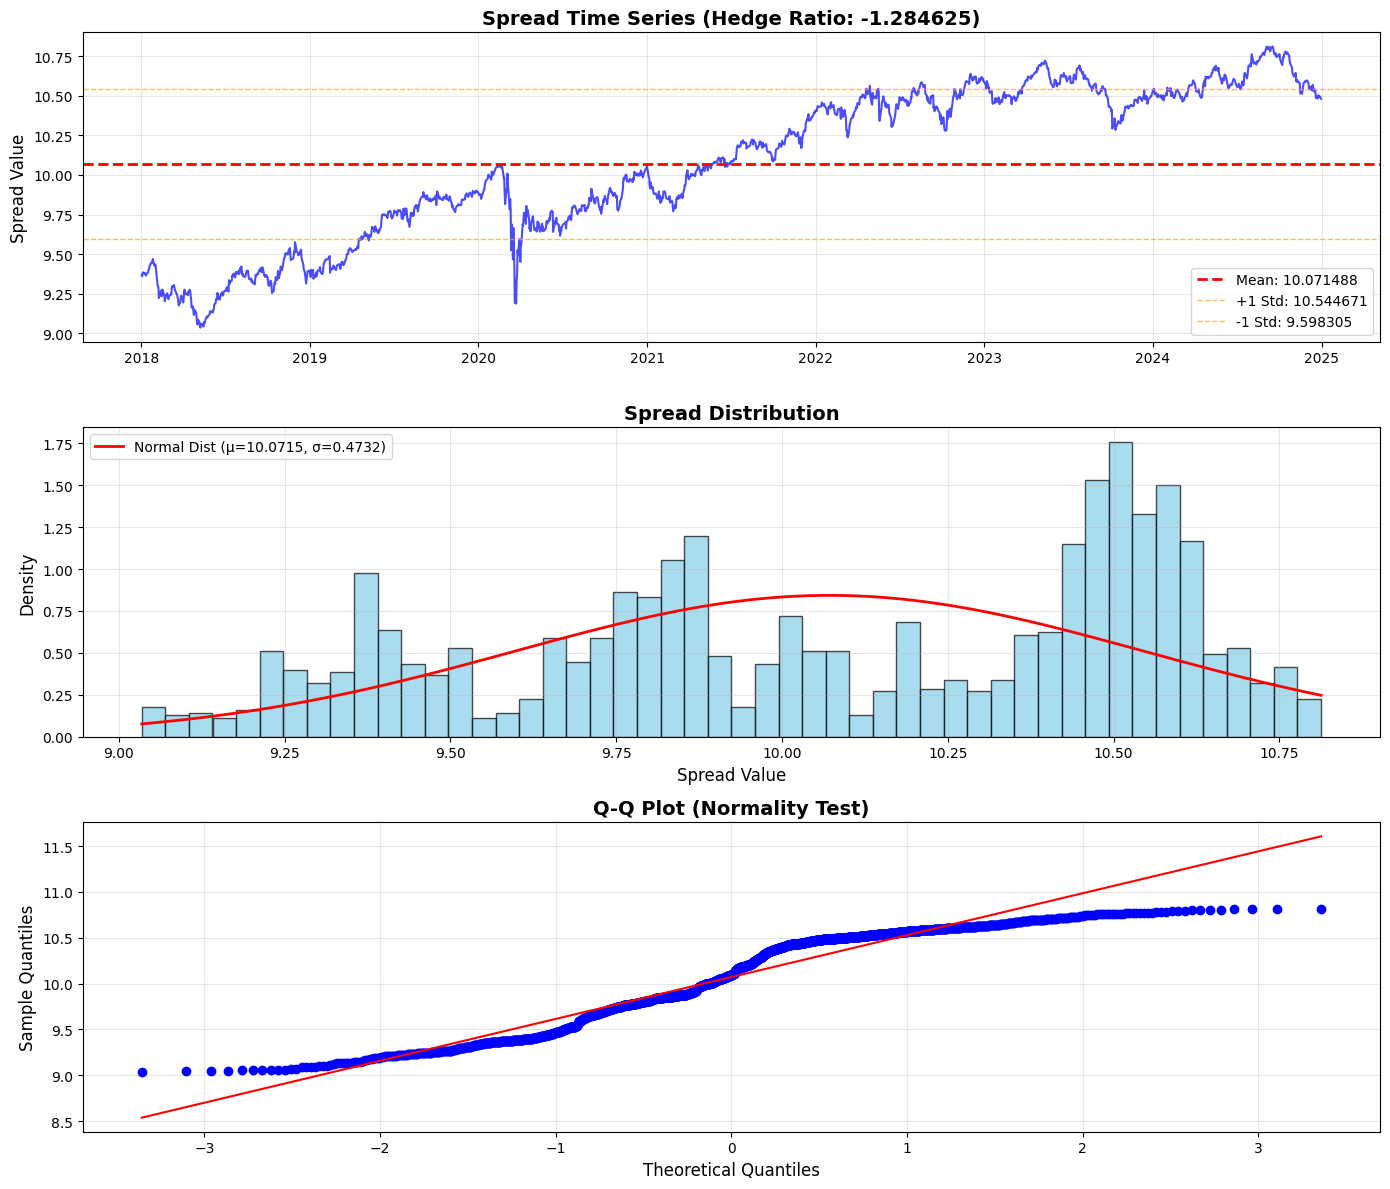


Detailed Spread Statistics:
Statistic            Value          
-----------------------------------
Mean                 10.071488      
Standard Deviation   0.473183       
Variance             0.223902       
Skewness             -0.344166      
Kurtosis             -1.150980      
Min                  9.034665       
Max                  10.812786      
Range                1.778121       

ADF Stationarity Test Results:
Test Statistic       -1.282516      
P-value              0.637133       
Significance Level   0.05           
Is Stationary        No             

Critical Values:
  1%                 -3.434101      
  5%                 -2.863197      
  10%                -2.567652      

Trading Implications:
  ❌ Spread is non-stationary - not suitable for mean reversion
  ❌ Consider different time period or parameter specifications
  ❌ May need to use alternative strategy


In [15]:
# Visualize spread time series and distribution
if stationarity_results:
    print("SPREAD VISUALIZATION AND ANALYSIS")
    print("=" * 80)
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    
    # Plot 1: Spread time series
    axes[0].plot(spread.index, spread, linewidth=1.5, color='blue', alpha=0.7)
    axes[0].axhline(y=spread.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {spread.mean():.6f}')
    axes[0].axhline(y=spread.mean() + spread.std(), color='orange', linestyle='--', linewidth=1, alpha=0.7, label=f'+1 Std: {spread.mean() + spread.std():.6f}')
    axes[0].axhline(y=spread.mean() - spread.std(), color='orange', linestyle='--', linewidth=1, alpha=0.7, label=f'-1 Std: {spread.mean() - spread.std():.6f}')
    axes[0].set_title(f'Spread Time Series (Hedge Ratio: {selected_hedge_ratio:.6f})', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Spread Value', fontsize=12)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Spread histogram with normal distribution overlay
    axes[1].hist(spread.dropna(), bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Overlay normal distribution
    from scipy import stats
    mu, sigma = spread.mean(), spread.std()
    x = np.linspace(spread.min(), spread.max(), 100)
    normal_dist = stats.norm.pdf(x, mu, sigma)
    axes[1].plot(x, normal_dist, 'r-', linewidth=2, label=f'Normal Dist (μ={mu:.4f}, σ={sigma:.4f})')
    axes[1].set_title('Spread Distribution', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Spread Value', fontsize=12)
    axes[1].set_ylabel('Density', fontsize=12)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Q-Q plot for normality test
    stats.probplot(spread.dropna(), dist="norm", plot=axes[2])
    axes[2].set_title('Q-Q Plot (Normality Test)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Theoretical Quantiles', fontsize=12)
    axes[2].set_ylabel('Sample Quantiles', fontsize=12)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Additional statistical analysis
    print(f"\nDetailed Spread Statistics:")
    print(f"{'Statistic':<20} {'Value':<15}")
    print("-" * 35)
    print(f"{'Mean':<20} {spread.mean():<15.6f}")
    print(f"{'Standard Deviation':<20} {spread.std():<15.6f}")
    print(f"{'Variance':<20} {spread.var():<15.6f}")
    print(f"{'Skewness':<20} {spread.skew():<15.6f}")
    print(f"{'Kurtosis':<20} {spread.kurtosis():<15.6f}")
    print(f"{'Min':<20} {spread.min():<15.6f}")
    print(f"{'Max':<20} {spread.max():<15.6f}")
    print(f"{'Range':<20} {spread.max() - spread.min():<15.6f}")
    
    # ADF Test Results Summary
    print(f"\nADF Stationarity Test Results:")
    print(f"{'Test Statistic':<20} {stationarity_results['adf_statistic']:<15.6f}")
    print(f"{'P-value':<20} {stationarity_results['p_value']:<15.6f}")
    print(f"{'Significance Level':<20} {stationarity_results['significance_level']:<15.2f}")
    print(f"{'Is Stationary':<20} {'Yes' if stationarity_results['is_stationary'] else 'No':<15}")
    
    print(f"\nCritical Values:")
    for key, value in stationarity_results['critical_values'].items():
        print(f"  {key:<18} {value:<15.6f}")
    
    # Trading implications
    print(f"\nTrading Implications:")
    if stationarity_results['is_stationary']:
        print(f"  ✅ Spread is stationary - suitable for mean reversion strategy")
        print(f"  ✅ Expected to revert to mean: {spread.mean():.6f}")
        print(f"  ✅ Standard deviation bands: ±{spread.std():.6f}")
        print(f"  ✅ Potential entry points: ±{2 * spread.std():.6f} (2 standard deviations)")
    else:
        print(f"  ❌ Spread is non-stationary - not suitable for mean reversion")
        print(f"  ❌ Consider different time period or parameter specifications")
        print(f"  ❌ May need to use alternative strategy")
    
else:
    print("❌ Cannot visualize spread - stationarity test failed!")

In [21]:
# Compare spreads across different hedge ratios
print("Comparing spreads across different hedge ratios...")

# Get hedge ratios from previous comparison
spread_comparison = []

for comparison in hedge_ratio_comparison:
    if comparison['is_valid']:  # Only use valid hedge ratios
        hr = comparison['hedge_ratio']
        
        # Calculate spread for this hedge ratio
        test_spread = calculate_spread(log_prices, hr)
        
        # Test stationarity
        stationarity = test_spread_stationarity(test_spread)
        
        if stationarity:
            spread_comparison.append({
                'det_order': comparison['det_order'],
                'k_ar_diff': comparison['k_ar_diff'],
                'hedge_ratio': hr,
                'spread_mean': test_spread.mean(),
                'spread_std': test_spread.std(),
                'adf_statistic': stationarity['adf_statistic'],
                'p_value': stationarity['p_value'],
                'is_stationary': stationarity['is_stationary'],
                'trace_stat': comparison['trace_stat']
            })

# Display spread comparison
print("\nSpread Comparison Across Hedge Ratios:")
print("-" * 110)
print(f"{'Det_Order':<10} {'Lags':<6} {'Hedge_Ratio':<12} {'Spread_Mean':<12} {'Spread_Std':<11} {'ADF_Stat':<10} {'P_Value':<10} {'Stationary':<11}")
print("-" * 110)

for comp in spread_comparison:
    stationary = "✅" if comp['is_stationary'] else "❌"
    print(f"{comp['det_order']:<10} {comp['k_ar_diff']:<6} "
          f"{comp['hedge_ratio']:<12.6f} {comp['spread_mean']:<12.6f} "
          f"{comp['spread_std']:<11.6f} {comp['adf_statistic']:<10.3f} "
          f"{comp['p_value']:<10.3f} {stationary:<11}")

print("-" * 110)

# Select best spread (stationary with lowest p-value)
stationary_spreads = [comp for comp in spread_comparison if comp['is_stationary']]
if stationary_spreads:
    best_spread = min(stationary_spreads, key=lambda x: x['p_value'])
    print(f"\nSelected Spread:")
    print(f"  Hedge Ratio: {best_spread['hedge_ratio']:.6f}")
    print(f"  Parameters: det_order={best_spread['det_order']}, k_ar_diff={best_spread['k_ar_diff']}")
    print(f"  ADF Statistic: {best_spread['adf_statistic']:.6f}")
    print(f"  P-value: {best_spread['p_value']:.6f}")
    print(f"  Reason: Most stationary spread (lowest p-value)")
    
    # Update selected hedge ratio if this one is better
    if best_spread['p_value'] < stationarity_results['p_value']:
        print(f"\n🔄 Updating to better hedge ratio: {best_spread['hedge_ratio']:.6f}")
        selected_hedge_ratio = best_spread['hedge_ratio']
        spread = calculate_spread(log_prices, selected_hedge_ratio)
        stationarity_results = test_spread_stationarity(spread)
else:
    print(f"\n⚠️  No stationary spreads found across all hedge ratios")
    print(f"Consider adjusting validation range or using different methodology")

print(f"\nInterpretation:")
print(f"- Stationary spreads (✅) are suitable for pairs trading")
print(f"- Lower p-values indicate stronger stationarity")
print(f"- Spread standard deviation affects trading signal sensitivity")

Comparing spreads across different hedge ratios...

Spread Comparison Across Hedge Ratios:
--------------------------------------------------------------------------------------------------------------
Det_Order  Lags   Hedge_Ratio  Spread_Mean  Spread_Std  ADF_Stat   P_Value    Stationary 
--------------------------------------------------------------------------------------------------------------
0          1      -1.296588    10.129376    0.475863    -1.283     0.637      ❌          
0          2      -1.285768    10.077017    0.473439    -1.283     0.637      ❌          
--------------------------------------------------------------------------------------------------------------

⚠️  No stationary spreads found across all hedge ratios
Consider adjusting validation range or using different methodology

Interpretation:
- Stationary spreads (✅) are suitable for pairs trading
- Lower p-values indicate stronger stationarity
- Spread standard deviation affects trading signal sensitivit